# Speculative Decoding：加速自回歸生成

> **難度：** 進階 | **時長：** 約三十五分鐘

自回歸LLM解碼，根本上受**記憶體所限**——GPU載入數十億參數，僅產一token。Speculative decoding打破此瓶頸：以小而快之**draft model**提議多個token，再由目標模型一次驗證。其數學保證確保輸出分布與標準解碼**完全一致**。

本篇所述：
1. 自回歸decode何以受記憶體所限——7B模型之arithmetic intensity分析
2. Draft-then-verify機制——以真實概率張量逐步模擬
3. 數學保證——acceptance criterion與輸出分布何以不變
4. 加速分析——expected tokens per round隨acceptance rate之變化
5. Draft model變體——自獨立模型至self-speculative decoding之比較

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))  
from mp_tutorial.inference import speculative_decode_step, compute_speculative_speedup
from mp_tutorial.inference_viz import draw_speculative_decoding_step, draw_speedup_vs_acceptance
from mp_tutorial.formatting import info_box, comparison_table
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

---
## 一、自回歸Decode之瓶頸

**Decode階段**中，LLM逐token生成。每步須自GPU記憶體（HBM）載入全部模型權重至計算單元——然僅行微小之矩陣向量乘法（batch size為1）。此使decode嚴重**受記憶體頻寬所限**。

**Arithmetic intensity**度量每byte記憶體流量所行之FLOPs數。當其低於GPU之compute-to-bandwidth ratio（即**roofline**），則受記憶體所限，計算單元閒置。

In [2]:
# Arithmetic intensity analysis for a 7B-parameter model

# Model specs (LLaMA-7B-like)
d_model = 4096
n_layers = 32
d_ff = 11008          # intermediate size (SwiGLU)
vocab_size = 32000
n_params = 7e9
dtype_bytes = 2       # FP16

model_bytes = n_params * dtype_bytes  # ~14 GB

# A100 GPU specs
a100_tflops = 312     # FP16 TFLOPS
a100_bw_tbs = 2.0     # TB/s HBM bandwidth
roofline = (a100_tflops * 1e12) / (a100_bw_tbs * 1e12)  # FLOPs per byte

print(f"=== LLaMA-7B Decode Step Analysis ===")
print(f"Model weights:     {model_bytes / 1e9:.1f} GB (FP16)")
print(f"A100 roofline:     {roofline:.0f} FLOPs/byte\n")

# Per-token FLOPs: ~2 FLOPs per parameter (1 multiply + 1 add)
flops_per_token = 2 * n_params

# Memory traffic: must load all weights from HBM
bytes_loaded = model_bytes  # dominated by weight reads

# Arithmetic intensity
intensity_decode = flops_per_token / bytes_loaded

print(f"--- Single-token decode (batch=1) ---")
print(f"FLOPs:             {flops_per_token:.2e}")
print(f"Bytes loaded:      {bytes_loaded:.2e}  (read all weights)")
print(f"Arithmetic intens: {intensity_decode:.1f} FLOPs/byte")
print(f"Roofline:          {roofline:.0f} FLOPs/byte")
print(f"")
print(f"Intensity ({intensity_decode:.0f}) << Roofline ({roofline:.0f})  =>  MEMORY-BOUND")
print(f"GPU compute utilization: {intensity_decode / roofline:.1%}")

=== LLaMA-7B Decode Step Analysis ===
Model weights:     14.0 GB (FP16)
A100 roofline:     156 FLOPs/byte

--- Single-token decode (batch=1) ---
FLOPs:             1.40e+10
Bytes loaded:      1.40e+10  (read all weights)
Arithmetic intens: 1.0 FLOPs/byte
Roofline:          156 FLOPs/byte

Intensity (1) << Roofline (156)  =>  MEMORY-BOUND
GPU compute utilization: 0.6%


In [3]:
# Time-per-token is dominated by memory bandwidth, not compute
time_memory_s = bytes_loaded / (a100_bw_tbs * 1e12)   # time to load weights
time_compute_s = flops_per_token / (a100_tflops * 1e12)  # time to compute

time_per_token_ms = max(time_memory_s, time_compute_s) * 1000
tokens_per_sec = 1.0 / max(time_memory_s, time_compute_s)

print(f"=== Time Breakdown (LLaMA-7B, A100, batch=1) ===")
print(f"Time to load weights:  {time_memory_s*1000:.2f} ms")
print(f"Time to compute:       {time_compute_s*1000:.4f} ms")
print(f"Bottleneck:            Memory bandwidth")
print(f"")
print(f"Effective decode:      {time_per_token_ms:.2f} ms/token  =>  {tokens_per_sec:.0f} tokens/sec")
print(f"")
print(f"Key insight: we load 14 GB of weights to produce ONE token.")
print(f"If we could verify K tokens in a single forward pass instead,")
print(f"we amortize that weight-loading cost across K tokens.")
print(f"This is the core idea behind speculative decoding.")

=== Time Breakdown (LLaMA-7B, A100, batch=1) ===
Time to load weights:  7.00 ms
Time to compute:       0.0449 ms
Bottleneck:            Memory bandwidth

Effective decode:      7.00 ms/token  =>  143 tokens/sec

Key insight: we load 14 GB of weights to produce ONE token.
If we could verify K tokens in a single forward pass instead,
we amortize that weight-loading cost across K tokens.
This is the core idea behind speculative decoding.


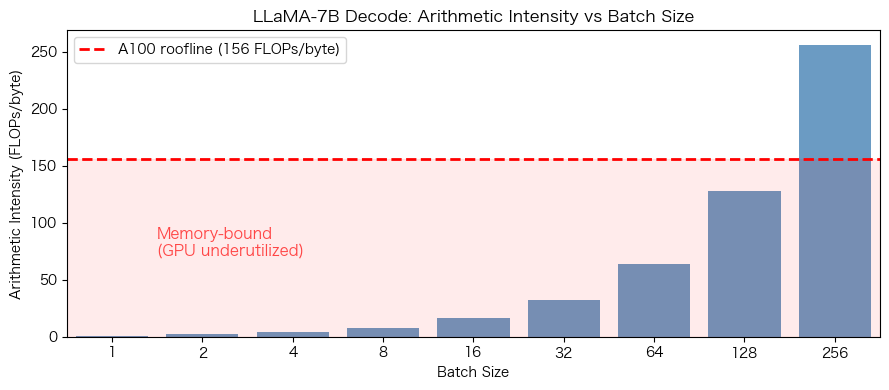

At batch=1, the GPU is only 0.6% utilized.
Speculative decoding exploits this idle compute by verifying K draft tokens at once.


In [4]:
# Visualize: arithmetic intensity for different batch sizes
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
intensities = [2 * n_params * bs / model_bytes for bs in batch_sizes]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(batch_sizes)), intensities, color='steelblue', alpha=0.8)
ax.axhline(y=roofline, color='red', linestyle='--', linewidth=2, label=f'A100 roofline ({roofline:.0f} FLOPs/byte)')
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels([str(b) for b in batch_sizes])
ax.set_xlabel('Batch Size')
ax.set_ylabel('Arithmetic Intensity (FLOPs/byte)')
ax.set_title('LLaMA-7B Decode: Arithmetic Intensity vs Batch Size')
ax.legend()

# Annotate memory-bound region
ax.fill_between([-0.5, len(batch_sizes)-0.5], 0, roofline, alpha=0.08, color='red')
ax.text(0.5, roofline * 0.45, 'Memory-bound\n(GPU underutilized)', fontsize=11,
        color='red', alpha=0.7, ha='left')

ax.set_xlim(-0.5, len(batch_sizes)-0.5)
plt.tight_layout()
plt.show()

print(f"At batch=1, the GPU is only {intensities[0]/roofline:.1%} utilized.")
print(f"Speculative decoding exploits this idle compute by verifying K draft tokens at once.")

---
## 二、Draft-Then-Verify：核心機制

Speculative decoding用**二模型**：
- **Draft model** $M_q$（小而快）——自回歸生成$K$個候選token
- **Target model** $M_p$（大而準）——以**一次**前向傳播驗證全部$K$個token

每輪算法如下：
1. Draft model生成$K$個token：$\hat{x}_1, \hat{x}_2, \ldots, \hat{x}_K$
2. Target model對全部$K$個token行**一次**前向傳播，產出各位置之$p(x_t | x_{<t})$
3. 對每個draft token，比較$p_{\text{target}}$與$q_{\text{draft}}$，接受或拒絕
4. 若token $i$被拒，則自調整分布中重新採樣，並棄$i+1, \ldots, K$

驗證之前向傳播與生成單個token之成本**幾近相同**（權重載入佔主導），然可產至多$K+1$個token。

In [5]:
# Step-by-step speculative decoding with a 10-token vocabulary, K=4
torch.manual_seed(42)

vocab_size = 10
K = 4  # number of draft tokens
token_names = ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'ran', 'big', 'red', 'end']

# Simulate draft model probabilities q(x_t) for K positions
# Draft model is smaller, so its distribution is "less confident" / different
q_logits = torch.randn(K, vocab_size)
q_probs = F.softmax(q_logits, dim=-1)

# Sample draft tokens from q
draft_tokens = torch.multinomial(q_probs, num_samples=1).squeeze(-1)

print("=== Draft Phase ===")
print(f"Draft model generates K={K} tokens:\n")
for i in range(K):
    tok_id = draft_tokens[i].item()
    print(f"  Position {i+1}: token '{token_names[tok_id]}' (id={tok_id})")
    print(f"    q('{token_names[tok_id]}') = {q_probs[i, tok_id]:.4f}")

print(f"\nDraft sequence: {' '.join(token_names[t] for t in draft_tokens)}")

=== Draft Phase ===
Draft model generates K=4 tokens:

  Position 1: token 'end' (id=9)
    q('end') = 0.2264
  Position 2: token 'end' (id=9)
    q('end') = 0.1216
  Position 3: token 'red' (id=8)
    q('red') = 0.1524
  Position 4: token 'sat' (id=2)
    q('sat') = 0.0128

Draft sequence: end end red sat


In [6]:
# Target model produces p(x_t) for each position in a single forward pass
# In practice, this is one forward pass with K tokens as input
torch.manual_seed(123)

# Target model probabilities (generally sharper / more confident)
p_logits = torch.randn(K, vocab_size) * 1.5  # higher temperature = sharper
p_probs = F.softmax(p_logits, dim=-1)

print("=== Verification Phase ===")
print("Target model evaluates all K positions in ONE forward pass:\n")
print(f"{'Pos':>3} | {'Draft Token':>11} | {'q(token)':>8} | {'p(token)':>8} | {'p/q ratio':>9}")
print("-" * 55)

for i in range(K):
    tok_id = draft_tokens[i].item()
    q_val = q_probs[i, tok_id].item()
    p_val = p_probs[i, tok_id].item()
    ratio = p_val / q_val
    print(f"{i+1:>3} | {token_names[tok_id]:>11} | {q_val:>8.4f} | {p_val:>8.4f} | {ratio:>9.3f}")

print(f"\nIf p/q >= 1: token is always accepted (target agrees or assigns higher prob).")
print(f"If p/q < 1:  token accepted with probability p/q (may be rejected).")

=== Verification Phase ===
Target model evaluates all K positions in ONE forward pass:

Pos | Draft Token | q(token) | p(token) | p/q ratio
-------------------------------------------------------
  1 |         end |   0.2264 |   0.0134 |     0.059
  2 |         end |   0.1216 |   0.1283 |     1.055
  3 |         red |   0.1524 |   0.0090 |     0.059
  4 |         sat |   0.0128 |   0.0488 |     3.797

If p/q >= 1: token is always accepted (target agrees or assigns higher prob).
If p/q < 1:  token accepted with probability p/q (may be rejected).


In [7]:
# Full acceptance/rejection loop
torch.manual_seed(7)

print("=== Token-by-Token Acceptance ===")
print()

accepted_tokens = []
first_rejected_pos = None

for i in range(K):
    tok_id = draft_tokens[i].item()
    q_val = q_probs[i, tok_id].item()
    p_val = p_probs[i, tok_id].item()
    
    # Acceptance probability: min(1, p/q)
    accept_prob = min(1.0, p_val / q_val)
    
    # Draw uniform random number
    r = torch.rand(1).item()
    accepted = r < accept_prob
    
    status = "ACCEPT" if accepted else "REJECT"
    print(f"  Position {i+1}: '{token_names[tok_id]}'")
    print(f"    accept_prob = min(1, {p_val:.4f}/{q_val:.4f}) = {accept_prob:.4f}")
    print(f"    random draw r = {r:.4f}  =>  {status}")
    
    if accepted:
        accepted_tokens.append(token_names[tok_id])
        print(f"    => Keep '{token_names[tok_id]}'")
    else:
        first_rejected_pos = i
        # Resample from adjusted distribution: norm(max(0, p - q))
        adjusted = torch.clamp(p_probs[i] - q_probs[i], min=0)
        adjusted = adjusted / adjusted.sum()
        resampled = torch.multinomial(adjusted, num_samples=1).item()
        accepted_tokens.append(token_names[resampled])
        print(f"    => Reject '{token_names[tok_id]}', resample '{token_names[resampled]}' from adjusted dist")
        print(f"    => Discard remaining draft tokens (positions {i+2} to {K})")
        break
    print()

# If all K accepted, sample one bonus token from p(x_{K+1})
if first_rejected_pos is None:
    print(f"\n  All {K} draft tokens accepted!")
    # Bonus token from target model's next-position distribution
    bonus_logits = torch.randn(vocab_size) * 1.5
    bonus_probs = F.softmax(bonus_logits, dim=-1)
    bonus_token = torch.multinomial(bonus_probs, num_samples=1).item()
    accepted_tokens.append(token_names[bonus_token])
    print(f"  + Bonus token from target model: '{token_names[bonus_token]}'")

print(f"\n=== Round Result ===")
print(f"Tokens produced this round: {len(accepted_tokens)}")
print(f"Accepted sequence: {' '.join(accepted_tokens)}")
print(f"\nCost: 1 target forward pass + K={K} draft forward passes")
print(f"Yield: {len(accepted_tokens)} tokens (vs 1 token from standard decoding)")

=== Token-by-Token Acceptance ===

  Position 1: 'end'
    accept_prob = min(1, 0.0134/0.2264) = 0.0592
    random draw r = 0.5349  =>  REJECT
    => Reject 'end', resample 'on' from adjusted dist
    => Discard remaining draft tokens (positions 2 to 4)

=== Round Result ===
Tokens produced this round: 1
Accepted sequence: on

Cost: 1 target forward pass + K=4 draft forward passes
Yield: 1 tokens (vs 1 token from standard decoding)


In [8]:
# Use the helper to run a complete speculative decode step
torch.manual_seed(42)

# Create reproducible draft and target distributions for K=4, vocab=10
q_probs_demo = F.softmax(torch.randn(K, vocab_size), dim=-1)
p_probs_demo = F.softmax(torch.randn(K, vocab_size) * 1.3, dim=-1)
# Extra position for bonus token
p_bonus = F.softmax(torch.randn(1, vocab_size) * 1.3, dim=-1)

result = speculative_decode_step(q_probs_demo, p_probs_demo, p_bonus, K=K)

print(f"Draft tokens:    {result['draft_tokens'].tolist()}")
print(f"Accepted mask:   {result['accepted_mask'].tolist()}")
print(f"Final tokens:    {result['final_tokens'].tolist()}")
print(f"Tokens produced: {result['n_produced']}")

Draft tokens:    [9, 7, 2, 5]
Accepted mask:   [True, True, True, False]
Final tokens:    [9, 7, 2, 4]
Tokens produced: 4


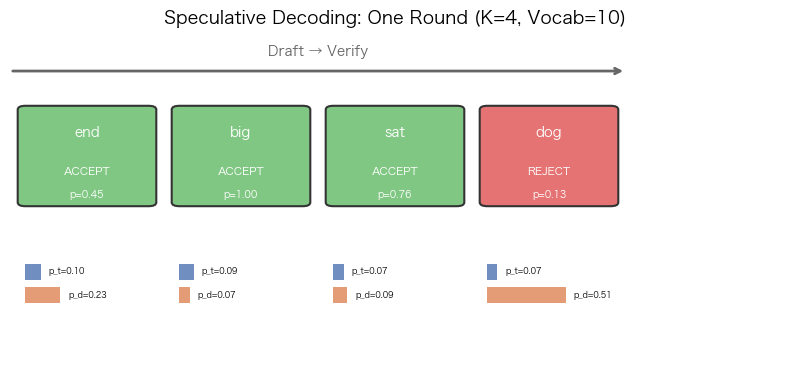

In [9]:
# Visualize one speculative decoding round
fig = draw_speculative_decoding_step(
    q_probs=q_probs_demo,
    p_probs=p_probs_demo,
    draft_tokens=result['draft_tokens'],
    accepted_mask=result['accepted_mask'],
    token_names=token_names,
    title="Speculative Decoding: One Round (K=4, Vocab=10)"
)
plt.show()

---
## 三、數學保證：輸出分布何以不變

Speculative decoding（Leviathan et al., 2023; Chen et al., 2023）之關鍵洞見在於：accept/reject方案所產之token，其分布**恰為**$p_{\text{target}}$，無論draft model優劣如何。

### Acceptance Criterion

對每個由$q(x)$採樣之draft token $x$：

$$\text{Accept with probability} = \min\left(1, \frac{p(x)}{q(x)}\right)$$

### 拒絕時：自調整分布重新採樣

若token被拒，則自以下分布採樣：

$$p_{\text{adjusted}}(x) = \text{norm}\Big(\max\big(0,\; p(x) - q(x)\big)\Big)$$

### 何以保全$p$？

最終輸出token $x$之概率為：

$$P(\text{output}=x) = \underbrace{q(x) \cdot \min\!\left(1, \frac{p(x)}{q(x)}\right)}_{\text{accept from draft}} + \underbrace{\left(\sum_{x'} q(x') \cdot \left(1 - \min\!\left(1, \frac{p(x')}{q(x')}\right)\right)\right) \cdot p_{\text{adjusted}}(x)}_{\text{reject then resample}}$$

第一項化簡為$\min(q(x), p(x))$。第二項貢獻餘量$\max(0, p(x) - q(x))$。合之：$p(x)$。

以下經驗驗證之。

In [10]:
# Empirical verification: run speculative decoding many times,
# check that the output distribution matches p_target exactly
torch.manual_seed(0)

vocab_size = 10
n_trials = 50000

# Fixed distributions for one position
p_target = F.softmax(torch.tensor([2.0, 1.0, 0.5, -0.5, -1.0, 0.3, -2.0, 1.5, 0.1, -0.8]), dim=-1)
q_draft  = F.softmax(torch.tensor([0.5, 1.5, 0.3, 0.2, -0.3, 1.0, -0.5, 0.8, 0.4, -0.1]), dim=-1)

output_counts = torch.zeros(vocab_size)

for _ in range(n_trials):
    # Sample from draft
    x = torch.multinomial(q_draft, 1).item()
    
    # Accept/reject
    accept_prob = min(1.0, (p_target[x] / q_draft[x]).item())
    if torch.rand(1).item() < accept_prob:
        output_counts[x] += 1
    else:
        # Resample from adjusted distribution
        adjusted = torch.clamp(p_target - q_draft, min=0)
        adjusted = adjusted / adjusted.sum()
        x_new = torch.multinomial(adjusted, 1).item()
        output_counts[x_new] += 1

empirical = output_counts / output_counts.sum()

print(f"{'Token':>6} | {'p_target':>8} | {'q_draft':>8} | {'Empirical':>9} | {'Error':>8}")
print("-" * 50)
for i in range(vocab_size):
    err = abs(empirical[i].item() - p_target[i].item())
    print(f"{token_names[i]:>6} | {p_target[i]:.4f}   | {q_draft[i]:.4f}   | {empirical[i]:.4f}    | {err:.4f}")

max_err = (empirical - p_target).abs().max().item()
print(f"\nMax absolute error: {max_err:.4f}  (expected ~0 with enough trials)")
print(f"Output matches p_target: {max_err < 0.01}")

 Token | p_target |  q_draft | Empirical |    Error
--------------------------------------------------
   the | 0.3649   | 0.0948   | 0.3606    | 0.0042
   cat | 0.1342   | 0.2577   | 0.1364    | 0.0022
   sat | 0.0814   | 0.0776   | 0.0816    | 0.0001
    on | 0.0299   | 0.0702   | 0.0301    | 0.0002
   mat | 0.0182   | 0.0426   | 0.0182    | 0.0000
   dog | 0.0667   | 0.1563   | 0.0670    | 0.0003
   ran | 0.0067   | 0.0349   | 0.0065    | 0.0002
   big | 0.2213   | 0.1280   | 0.2232    | 0.0019
   red | 0.0546   | 0.0858   | 0.0547    | 0.0001
   end | 0.0222   | 0.0520   | 0.0217    | 0.0005

Max absolute error: 0.0042  (expected ~0 with enough trials)
Output matches p_target: True


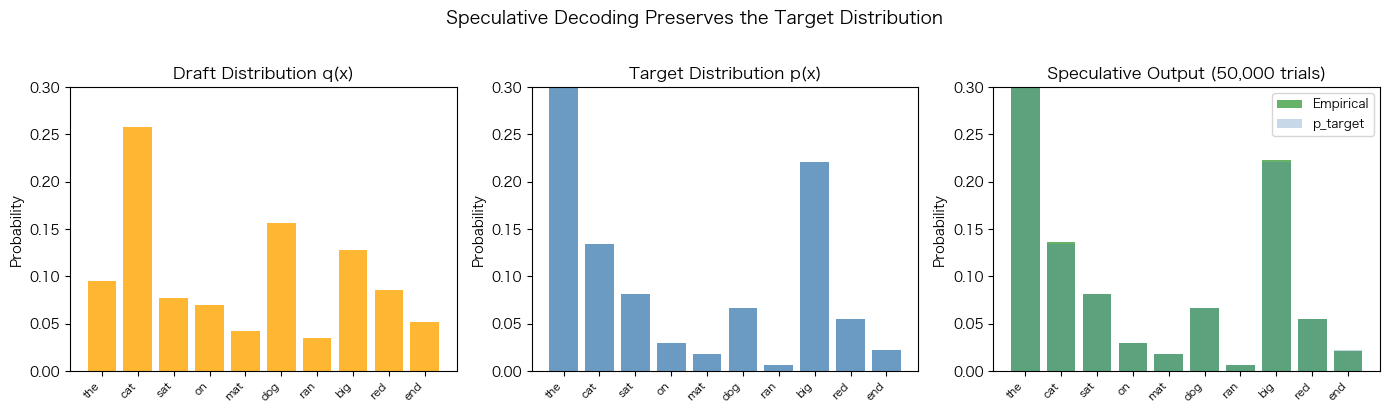

In [11]:
# Visualize: p_target vs q_draft vs empirical output
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x_pos = range(vocab_size)

axes[0].bar(x_pos, q_draft.numpy(), color='orange', alpha=0.8)
axes[0].set_title('Draft Distribution q(x)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(token_names, rotation=45, ha='right', fontsize=8)
axes[0].set_ylim(0, 0.3)

axes[1].bar(x_pos, p_target.numpy(), color='steelblue', alpha=0.8)
axes[1].set_title('Target Distribution p(x)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(token_names, rotation=45, ha='right', fontsize=8)
axes[1].set_ylim(0, 0.3)

axes[2].bar(x_pos, empirical.numpy(), color='green', alpha=0.6, label='Empirical')
axes[2].bar(x_pos, p_target.numpy(), color='steelblue', alpha=0.3, label='p_target')
axes[2].set_title(f'Speculative Output ({n_trials:,} trials)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(token_names, rotation=45, ha='right', fontsize=8)
axes[2].set_ylim(0, 0.3)
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_ylabel('Probability')

plt.suptitle('Speculative Decoding Preserves the Target Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# Walk through the math step by step for one token
print("=== Mathematical Proof (by example) ===")
print()

# Pick token 'the' (index 0)
x = 0
p_x = p_target[x].item()
q_x = q_draft[x].item()

print(f"For token '{token_names[x]}': p={p_x:.4f}, q={q_x:.4f}\n")

# Term 1: probability of drafting x and accepting it
accept_prob = min(1.0, p_x / q_x)
term1 = q_x * accept_prob
print(f"Term 1 (draft & accept):")
print(f"  q(x) * min(1, p(x)/q(x)) = {q_x:.4f} * min(1, {p_x:.4f}/{q_x:.4f})")
print(f"  = {q_x:.4f} * {accept_prob:.4f} = {term1:.4f}")
print(f"  = min(q(x), p(x)) = min({q_x:.4f}, {p_x:.4f}) = {min(q_x, p_x):.4f}")

# Total rejection probability
reject_total = 0
for x_prime in range(vocab_size):
    a = min(1.0, p_target[x_prime].item() / q_draft[x_prime].item())
    reject_total += q_draft[x_prime].item() * (1 - a)

print(f"\nTotal rejection probability: {reject_total:.4f}")

# Term 2: probability of rejecting some other token and resampling x
adjusted = torch.clamp(p_target - q_draft, min=0)
Z = adjusted.sum().item()
p_adj_x = max(0, p_x - q_x) / Z

term2 = reject_total * p_adj_x
print(f"\nTerm 2 (reject & resample):")
print(f"  P(reject) * p_adj(x) = {reject_total:.4f} * max(0, {p_x:.4f}-{q_x:.4f})/{Z:.4f}")
print(f"  = {reject_total:.4f} * {p_adj_x:.4f} = {term2:.4f}")

total = term1 + term2
print(f"\nTotal: P(output='{token_names[x]}') = {term1:.4f} + {term2:.4f} = {total:.4f}")
print(f"Target:                     p('{token_names[x]}') = {p_x:.4f}")
print(f"Match: {abs(total - p_x) < 1e-6}")

=== Mathematical Proof (by example) ===

For token 'the': p=0.3649, q=0.0948

Term 1 (draft & accept):
  q(x) * min(1, p(x)/q(x)) = 0.0948 * min(1, 0.3649/0.0948)
  = 0.0948 * 1.0000 = 0.0948
  = min(q(x), p(x)) = min(0.0948, 0.3649) = 0.0948

Total rejection probability: 0.3671

Term 2 (reject & resample):
  P(reject) * p_adj(x) = 0.3671 * max(0, 0.3649-0.0948)/0.3671
  = 0.3671 * 0.7355 = 0.2700

Total: P(output='the') = 0.0948 + 0.2700 = 0.3649
Target:                     p('the') = 0.3649
Match: True


拒絕概率$\sum_{x'} q(x')(1 - \min(1, p(x')/q(x')))$等於$\sum_{x'} \max(0, q(x') - p(x'))$，此恰為調整分布之歸一化常數$Z$。故第二項化簡：

$$\text{Term 2} = Z \cdot \frac{\max(0, p(x) - q(x))}{Z} = \max(0, p(x) - q(x))$$

於是：$\text{Term 1} + \text{Term 2} = \min(p(x), q(x)) + \max(0, p(x) - q(x)) = p(x)$。

---
## 四、加速分析

### Expected Tokens Per Round

設$\alpha$為**平均token acceptance rate**——各位置draft token被接受之概率。若draft $K$個token，每輪speculative decoding之expected tokens為：

$$E[\text{tokens per round}] = \frac{1 - \alpha^{K+1}}{1 - \alpha}$$

此為幾何級數：位置$i$被達到，須前$i-1$個token皆被接受（概率$\alpha^{i-1}$），貢獻1 token。全$K$被接受時另得bonus token，故$+1$。

### Wall-Clock Speedup

若draft model較target model便宜$c$倍（典型小draft之$c \approx 0.05$--$0.1$），則對標準解碼之加速約為：

$$\text{Speedup} \approx \frac{E[\text{tokens per round}]}{1 + c \cdot K}$$

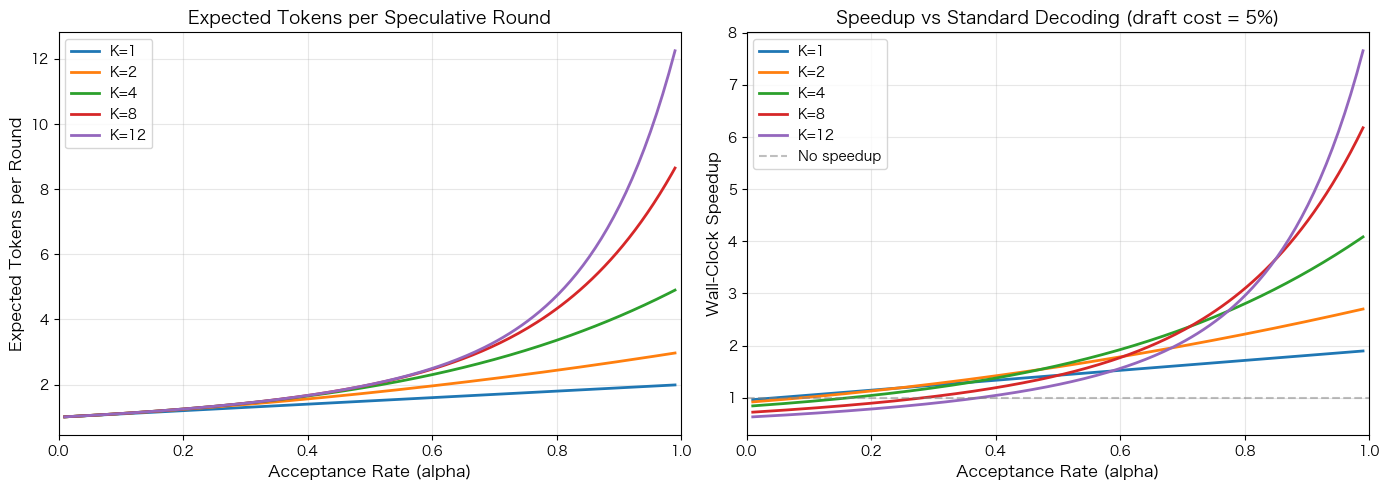

 alpha | K=4 tokens | K=4 speedup | K=8 tokens | K=8 speedup
------------------------------------------------------------
  0.50 |       1.94 |       1.61x |       2.00 |       1.43x
  0.70 |       2.77 |       2.31x |       3.20 |       2.28x
  0.80 |       3.36 |       2.80x |       4.33 |       3.09x
  0.90 |       4.10 |       3.41x |       6.13 |       4.38x
  0.95 |       4.52 |       3.77x |       7.40 |       5.28x


In [13]:
# Expected tokens per round as a function of acceptance rate
alphas = np.linspace(0.01, 0.99, 200)

K_values = [1, 2, 4, 8, 12]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: expected tokens per round
for K_val in K_values:
    expected = (1 - alphas**(K_val + 1)) / (1 - alphas)
    ax1.plot(alphas, expected, label=f'K={K_val}', linewidth=2)

ax1.set_xlabel('Acceptance Rate (alpha)', fontsize=12)
ax1.set_ylabel('Expected Tokens per Round', fontsize=12)
ax1.set_title('Expected Tokens per Speculative Round', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)

# Right: wall-clock speedup (assuming draft cost = 0.05x target)
c = 0.05  # draft model cost ratio
for K_val in K_values:
    expected = (1 - alphas**(K_val + 1)) / (1 - alphas)
    speedup = expected / (1 + c * K_val)
    ax2.plot(alphas, speedup, label=f'K={K_val}', linewidth=2)

ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='No speedup')
ax2.set_xlabel('Acceptance Rate (alpha)', fontsize=12)
ax2.set_ylabel('Wall-Clock Speedup', fontsize=12)
ax2.set_title(f'Speedup vs Standard Decoding (draft cost = {c:.0%})', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Print some concrete numbers
print(f"{'alpha':>6} | {'K=4 tokens':>10} | {'K=4 speedup':>11} | {'K=8 tokens':>10} | {'K=8 speedup':>11}")
print("-" * 60)
for a in [0.5, 0.7, 0.8, 0.9, 0.95]:
    t4 = (1 - a**5) / (1 - a)
    s4 = t4 / (1 + c * 4)
    t8 = (1 - a**9) / (1 - a)
    s8 = t8 / (1 + c * 8)
    print(f"{a:>6.2f} | {t4:>10.2f} | {s4:>10.2f}x | {t8:>10.2f} | {s8:>10.2f}x")

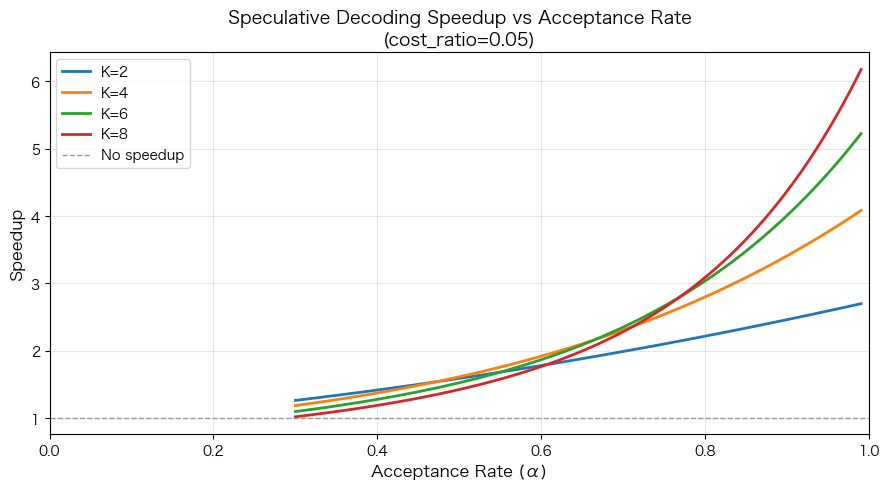

In [14]:
# Use the helper to compute and display speedup analysis
speedup_data = compute_speculative_speedup(
    alpha_range=(0.3, 0.99),
    K_values=[2, 4, 6, 8],
    draft_cost_ratio=0.05
)

# Visualize with helper
fig = draw_speedup_vs_acceptance(
    speedup_data,
    title="Speculative Decoding Speedup vs Acceptance Rate"
)
plt.show()

In [15]:
# Optimal K depends on acceptance rate and draft cost
print("=== Optimal K Selection ===")
print("(For draft cost ratio c = 0.05)\n")

c = 0.05
K_range = range(1, 21)

print(f"{'alpha':>6} | {'Optimal K':>9} | {'Max Speedup':>11} | {'Tokens/round':>12}")
print("-" * 50)

for alpha in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    best_K, best_speedup, best_tokens = 1, 0, 0
    for K_val in K_range:
        tokens = (1 - alpha**(K_val + 1)) / (1 - alpha)
        speedup = tokens / (1 + c * K_val)
        if speedup > best_speedup:
            best_K = K_val
            best_speedup = speedup
            best_tokens = tokens
    print(f"{alpha:>6.2f} | {best_K:>9} | {best_speedup:>10.2f}x | {best_tokens:>12.2f}")

print(f"\nKey insight: higher acceptance rate allows larger K.")
print(f"When alpha is low, large K wastes draft compute on tokens that will be rejected.")
print(f"When alpha is high (>0.9), K=8-12 yields 3-5x speedup.")

=== Optimal K Selection ===
(For draft cost ratio c = 0.05)

 alpha | Optimal K | Max Speedup | Tokens/round
--------------------------------------------------
  0.50 |         3 |       1.63x |         1.88
  0.60 |         4 |       1.92x |         2.31
  0.70 |         6 |       2.35x |         3.06
  0.80 |         8 |       3.09x |         4.33
  0.90 |        13 |       4.67x |         7.71
  0.95 |        20 |       6.59x |        13.19

Key insight: higher acceptance rate allows larger K.
When alpha is low, large K wastes draft compute on tokens that will be rejected.
When alpha is high (>0.9), K=8-12 yields 3-5x speedup.


=== Empirical Simulation (alpha=0.8, K=4, 5000 rounds) ===
Empirical avg tokens/round:    3.348
Theoretical avg tokens/round:  3.362



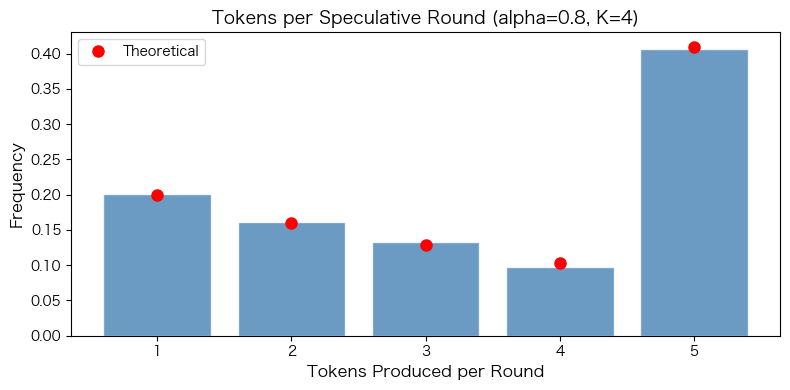

In [16]:
# Simulate speculative decoding over many rounds to measure empirical speedup
torch.manual_seed(42)

n_rounds = 5000
K = 4
alpha = 0.8  # per-token acceptance rate

total_tokens = 0
tokens_per_round_hist = []

for _ in range(n_rounds):
    n_accepted = 0
    for k in range(K):
        if torch.rand(1).item() < alpha:
            n_accepted += 1
        else:
            break
    # Always get at least 1 token (resampled or bonus)
    produced = n_accepted + 1
    total_tokens += produced
    tokens_per_round_hist.append(produced)

empirical_avg = total_tokens / n_rounds
theoretical_avg = (1 - alpha**(K+1)) / (1 - alpha)

print(f"=== Empirical Simulation (alpha={alpha}, K={K}, {n_rounds} rounds) ===")
print(f"Empirical avg tokens/round:    {empirical_avg:.3f}")
print(f"Theoretical avg tokens/round:  {theoretical_avg:.3f}")
print(f"")

# Histogram of tokens per round
fig, ax = plt.subplots(figsize=(8, 4))
values, counts = np.unique(tokens_per_round_hist, return_counts=True)
ax.bar(values, counts / n_rounds, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('Tokens Produced per Round', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Tokens per Speculative Round (alpha={alpha}, K={K})', fontsize=13)
ax.set_xticks(values)

# Add theoretical probabilities
for v in values:
    if v <= K:
        # Probability of exactly v tokens: alpha^(v-1) * (1-alpha) for v < K+1
        theo_prob = alpha**(v-1) * (1 - alpha)
    else:
        # Probability of K+1 tokens: alpha^K
        theo_prob = alpha**K
    ax.plot(v, theo_prob, 'ro', markersize=8, zorder=5)

ax.plot([], [], 'ro', markersize=8, label='Theoretical')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 五、Draft Model變體

Draft model之選擇至為關鍵——須足夠快，使draft $K$個token之成本遠低於target一次前向傳播；又須足夠準，以維持高acceptance rate $\alpha$。

已有數種架構被提出：

In [17]:
comparison_table(
    title="Draft Model Variants for Speculative Decoding",
    headers=["Method", "Draft Source", "Key Idea", "Acceptance Rate", "Extra Training?", "Overhead"],
    rows=[
        [
            "Independent\nSmall Model",
            "Separate smaller LLM\n(e.g., 68M for 7B target)",
            "Standard spec. decode;\ndraft is a smaller model\nfrom same family",
            "Moderate\n(alpha ~ 0.6-0.8)",
            "No (use existing\nsmaller model)",
            "Draft model weights\nin memory",
        ],
        [
            "Medusa\n(multi-head)",
            "Extra prediction heads\non target model",
            "K extra LM heads predict\ntokens at positions +1..+K\nin parallel (no autoregression)",
            "Moderate-High\n(alpha ~ 0.6-0.85)",
            "Yes (train K heads\non target model)",
            "K small linear heads\n(< 1% params)",
        ],
        [
            "EAGLE",
            "Lightweight AR head\non target features",
            "Autoregressively predicts\nnext-token features (not\nlogits), uses tree attention",
            "High\n(alpha ~ 0.8-0.9)",
            "Yes (train feature\nprediction head)",
            "1 transformer layer\n(~2% params)",
        ],
        [
            "Self-Speculative\nDecoding",
            "Target model itself\n(layer skipping)",
            "Skip layers in target model\nfor fast draft; full model\nfor verify. No extra model.",
            "Moderate\n(alpha ~ 0.5-0.7)",
            "No (or minimal\nfine-tuning)",
            "None (reuses\ntarget model)",
        ],
        [
            "Lookahead\nDecoding",
            "N-gram cache from\nJacobi iterations",
            "Parallel Jacobi iteration\ngenerates n-gram candidates;\nverified by target model",
            "Variable\n(depends on n-gram hits)",
            "No",
            "N-gram cache\nmemory",
        ],
    ]
)

Method,Draft Source,Key Idea,Acceptance Rate,Extra Training?,Overhead
Independent Small Model,"Separate smaller LLM (e.g., 68M for 7B target)",Standard spec. decode; draft is a smaller model from same family,Moderate (alpha ~ 0.6-0.8),No (use existing smaller model),Draft model weights in memory
Medusa (multi-head),Extra prediction heads on target model,K extra LM heads predict tokens at positions +1..+K in parallel (no autoregression),Moderate-High (alpha ~ 0.6-0.85),Yes (train K heads on target model),K small linear heads (< 1% params)
EAGLE,Lightweight AR head on target features,"Autoregressively predicts next-token features (not logits), uses tree attention",High (alpha ~ 0.8-0.9),Yes (train feature prediction head),1 transformer layer (~2% params)
Self-Speculative Decoding,Target model itself (layer skipping),Skip layers in target model for fast draft; full model for verify. No extra model.,Moderate (alpha ~ 0.5-0.7),No (or minimal fine-tuning),None (reuses target model)
Lookahead Decoding,N-gram cache from Jacobi iterations,Parallel Jacobi iteration generates n-gram candidates; verified by target model,Variable (depends on n-gram hits),No,N-gram cache memory


Variant                   | alpha | Draft cost |  K | Tokens/round | Speedup
---------------------------------------------------------------------------
Independent (68M)         |  0.70 |       0.03 |  5 |         2.94 |   2.56x
Medusa (multi-head)       |  0.75 |       0.01 |  5 |         3.29 |   3.13x
EAGLE                     |  0.85 |       0.02 |  6 |         4.53 |   4.04x
Self-Speculative          |  0.60 |       0.40 |  3 |         2.18 |   0.99x


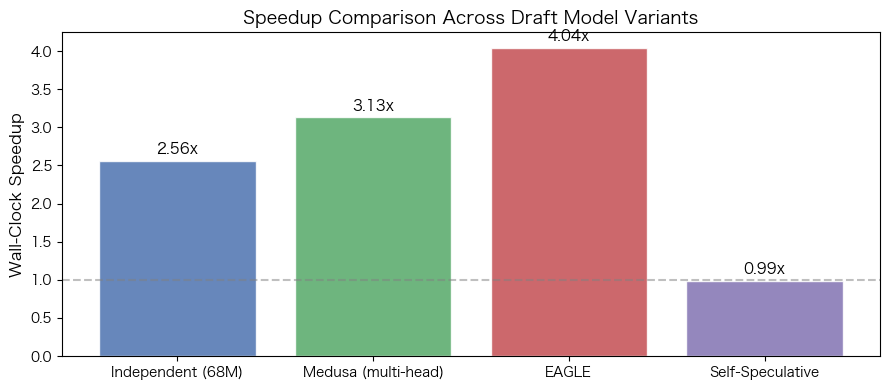

In [18]:
# Compare speedup profiles for different draft model quality/cost tradeoffs
variants = [
    {"name": "Independent (68M)",   "alpha": 0.70, "cost": 0.03, "K": 5},
    {"name": "Medusa (multi-head)",  "alpha": 0.75, "cost": 0.01, "K": 5},
    {"name": "EAGLE",                "alpha": 0.85, "cost": 0.02, "K": 6},
    {"name": "Self-Speculative",     "alpha": 0.60, "cost": 0.40, "K": 3},
]

print(f"{'Variant':<25} | {'alpha':>5} | {'Draft cost':>10} | {'K':>2} | {'Tokens/round':>12} | {'Speedup':>7}")
print("-" * 75)

speedups = []
for v in variants:
    alpha, c_val, K_val = v["alpha"], v["cost"], v["K"]
    tokens = (1 - alpha**(K_val + 1)) / (1 - alpha)
    speedup = tokens / (1 + c_val * K_val)
    speedups.append(speedup)
    print(f"{v['name']:<25} | {alpha:>5.2f} | {c_val:>10.2f} | {K_val:>2} | {tokens:>12.2f} | {speedup:>6.2f}x")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = ax.bar(range(len(variants)), speedups, color=colors, alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(variants)))
ax.set_xticklabels([v["name"] for v in variants], fontsize=10)
ax.set_ylabel('Wall-Clock Speedup', fontsize=12)
ax.set_title('Speedup Comparison Across Draft Model Variants', fontsize=13)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

for bar, s in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{s:.2f}x', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 權衡要點

- **Acceptance rate與draft cost**：draft model能力愈強，$\alpha$愈高，然每token成本亦愈高。最佳點在於最大化$E[\text{tokens}] / (1 + cK)$。
- **記憶體開銷**：獨立draft model須載入第二組權重。Medusa與EAGLE僅於target model上添少量參數。
- **訓練成本**：EAGLE等方法需訓練額外模塊，而self-speculative與獨立模型方法開箱即用。
- **Tree attention**：EAGLE與Medusa常用**tree-structured**驗證而非單鏈，於一次傳播中探索多條候選續寫。此提升acceptance rate，代價為更複雜之KV-cache管理。

---
## 總結

| 概念 | 要義 | 效果 |
|---------|----------|--------|
| **記憶體受限之decode** | 載入模型權重佔主導；batch=1時GPU計算利用率低 | Arithmetic intensity約1，roofline約156 FLOPs/byte |
| **Draft-then-verify** | 小模型draft K token；target一次驗證 | 將權重載入成本攤於多token |
| **Acceptance criterion** | 以$\min(1, p/q)$接受；拒絕則自$\text{norm}(\max(0, p-q))$重採樣 | 輸出分布**恰為**$p_{\text{target}}$ |
| **Expected tokens** | $(1 - \alpha^{K+1})/(1 - \alpha)$ per round | 典型$\alpha \in [0.7, 0.9]$時2-5倍加速 |
| **Draft變體** | 獨立模型、Medusa、EAGLE、self-speculative | 精度/成本/記憶體各有權衡 |

Speculative decoding乃最具影響力之推理優化之一，蓋其提供**無損**加速——輸出分布與標準解碼數學上完全一致。配合KV-cache（第00篇）、continuous batching（第02篇）與PagedAttention（第03篇），構成完整之服務優化棧。

### 延伸閱讀
- [Fast Inference from Transformers via Speculative Decoding (Leviathan et al., 2023)](https://arxiv.org/abs/2211.17192)
- [Accelerating Large Language Model Decoding with Speculative Sampling (Chen et al., 2023)](https://arxiv.org/abs/2302.01318)
- [Medusa: Simple LLM Inference Acceleration with Multiple Decoding Heads (Cai et al., 2024)](https://arxiv.org/abs/2401.10774)
- [EAGLE: Speculative Sampling Requires Rethinking Feature Uncertainty (Li et al., 2024)](https://arxiv.org/abs/2401.15077)
- 次篇：**[07-model-compilation](07-model-compilation.ipynb)** —— 以torch.compile與graph capture加速推理